# Python Lesson 32: Exponential Function e^x and Logarithm

**Concept page:** `wiki/concepts/exponential-and-logarithm.md` · **Area:** calculus

**You will be able to:**
- derive e as a limit (compound interest)
- check (e^x)'=e^x and (ln x)'=1/x
- solve exponential inequalities with logs

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Compound interest: which bank wins?

In [2]:
for n in (1,2,3,12,365,10**6): print(f"{n:>7d} periods -> {(1+1/n)**n:.5f}")
print("e =", np.e)

      1 periods -> 2.00000
      2 periods -> 2.25000
      3 periods -> 2.37037
     12 periods -> 2.61304
    365 periods -> 2.71457
1000000 periods -> 2.71828
e = 2.718281828459045


## 2. e^x is its own derivative; ln is its inverse

In [3]:
for h in (1,0.5,0.25,0.125,0.001): print(h,(np.exp(2+h)-np.exp(2))/h)   # -> e^2 = 7.389
x=sp.symbols('x'); print(sp.diff(sp.exp(x),x), sp.diff(sp.log(x),x), sp.diff(2**x,x))

1 12.696480824257018
0.5 9.586875723545646
0.25 8.394718949711503
0.125 7.870731113572916
0.001 7.392751858796842
exp(x) 1/x 2**x*log(2)


## 3. The population example from the textbook

36.860231685036425


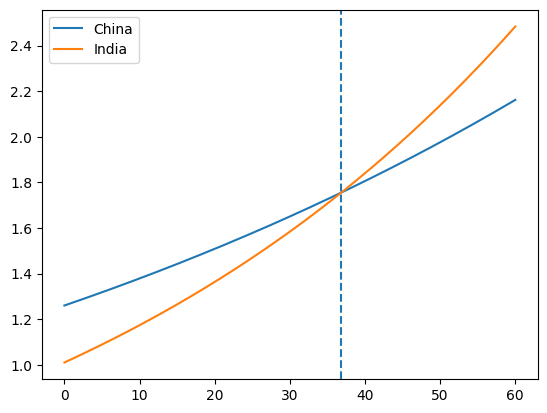

In [4]:
# India I(t)=1.01 e^{0.015 t}  vs  China C(t)=1.26 e^{0.009 t}: when does I > C ?
t=(np.log(1.26)-np.log(1.01))/0.006; print(t)
tt=np.linspace(0,60,200); plt.plot(tt,1.26*np.exp(0.009*tt),label="China"); plt.plot(tt,1.01*np.exp(0.015*tt),label="India"); plt.axvline(t,ls='--'); plt.legend(); plt.show()

In [5]:
x=np.array([1,10,100,1e4,1e6]); print(np.log(x)/x)    # ln x / x -> 0

[0.     0.2303 0.0461 0.0009 0.    ]


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic p. 104: I(t)=1.01e^{0.015t}, C(t)=1.26e^{0.009t} ⇒ t > 36.86 years.

In [6]:
print((np.log(1.26)-np.log(1.01))/0.006)

36.860231685036425


**Grade 11 advanced ch. 2:** exponential equations and inequalities (the sign flips when the base is below 1).

In [7]:
x=sp.symbols('x',real=True)
print(sp.solve(sp.Eq(2**(3*x+5),128),x),sp.solve(sp.Eq(49**x,7**(x**2-15)),x),sp.solve(sp.Eq(36**(2*x),216**(x-1)),x))
print(sp.solve_univariate_inequality(2**(3*x+1)<sp.Rational(1,32),x), sp.solve_univariate_inequality((sp.Rational(2,3))**(-3*x)>sp.Rational(16,81),x))
print(sp.solve_univariate_inequality(2**(9*x-x**3)<1,x))
assert sp.solve(sp.Eq(2**(3*x+5),128),x)==[sp.Rational(2,3)]

[2/3] [-3, 5] [-3]
x < -2 -4/3 < x
(3 < x) | ((-3 < x) & (x < 0))


**Logarithm equations and inequalities (G11 advanced, pp. 49-54):** always check the domain; the inequality reverses when the base is below 1.

In [8]:
xs=np.linspace(0.001,30,300000)
ok1=(3*xs-5>0)&(xs+7>0)&(np.log(3*xs-5)>np.log(xs+7))        # log base 3: same direction as the arguments
ok2=(2*xs-1>0)&(np.log(2*xs-1)/np.log(0.5)<=2)               # base 1/2: reversed
print(xs[ok1].min(),xs[ok2].min())                             # ~6 and ~5/8
x=sp.symbols('x',positive=True); print(sp.solve(sp.Eq((2*sp.log(x,9)-1)*(sp.log(x,9)-2),0),x),sp.solve(sp.Eq(sp.log(x,9),sp.Rational(3,2)),x))
assert abs(xs[ok1].min()-6)<1e-3 and abs(xs[ok2].min()-0.625)<1e-3

6.0000200234000785 0.6250812769375897
[3, 81] [27]


/var/folders/jb/x1g52tbx7bn4c1t25tm3rh5m0000gn/T/ipykernel_18889/795310380.py:2: RuntimeWarning: invalid value encountered in log
  ok1=(3*xs-5>0)&(xs+7>0)&(np.log(3*xs-5)>np.log(xs+7))        # log base 3: same direction as the arguments
/var/folders/jb/x1g52tbx7bn4c1t25tm3rh5m0000gn/T/ipykernel_18889/795310380.py:3: RuntimeWarning: invalid value encountered in log
  ok2=(2*xs-1>0)&(np.log(2*xs-1)/np.log(0.5)<=2)               # base 1/2: reversed


## Exercises

**Exercise 1.** Solve 0.0256 = 0.4^n for n using logs (answer 4).

In [9]:
# your code here

**Exercise 2.** Verify numerically that ln(ab)=ln a+ln b for a=3, b=7.

In [10]:
# your code here

## Solutions
*(Try the exercises first!)*

In [11]:
# Solution 1
n=np.log(0.0256)/np.log(0.4); print(n); assert abs(n-4)<1e-9

4.000000000000001


In [12]:
# Solution 2
assert np.isclose(np.log(21),np.log(3)+np.log(7))